# Assignment 1: Question 4 (Solution)

In [ ]:
$$ As

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
# Define f(t, y) for logistic growth
def f(t, y):
    return y*(1-y)

# Exact solution
def y_exact(t):
    return 1/(1 + 9*np.exp(-t))
    
def euler(f, y0, h, t_end):
    t_vals = np.arange(0, t_end+h, h)
    y_vals = np.zeros_like(t_vals)
    y_vals[0] = y0
    for n in range(len(t_vals)-1):
        y_vals[n+1] = y_vals[n] + h*f(t_vals[n], y_vals[n])
    return t_vals, y_vals

def rk4(f, y0, h, t_end):
    t_vals = np.arange(0, t_end+h, h)
    y_vals = np.zeros_like(t_vals)
    y_vals[0] = y0
    for n in range(len(t_vals)-1):
        t, y = t_vals[n], y_vals[n]
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2*k1)
        k3 = f(t + h/2, y + h/2*k2)
        k4 = f(t + h, y + h*k3)
        y_vals[n+1] = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t_vals, y_vals



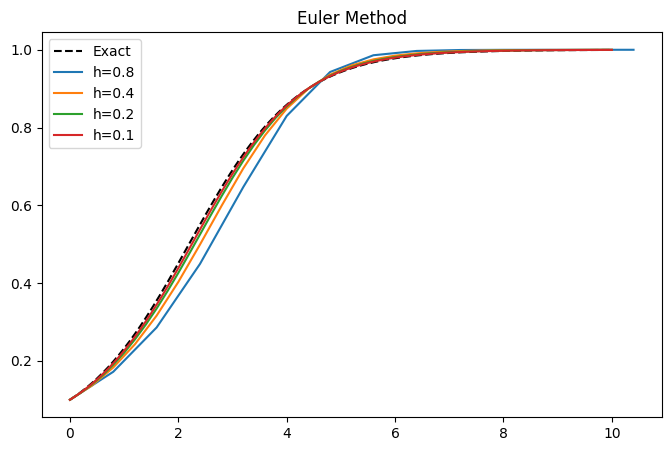

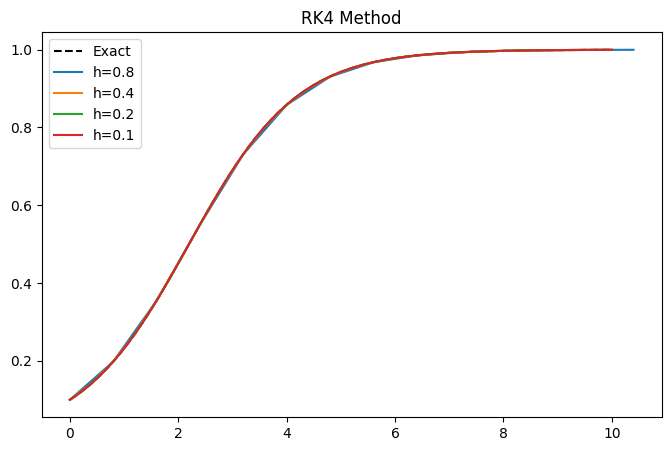

In [3]:
hs = [0.8,0.4,0.2,0.1]

# Euler plots
plt.figure(figsize=(8,5))
t_exact = np.linspace(0,10,400)
plt.plot(t_exact, y_exact(t_exact), 'k--', label="Exact")
for h in hs:
    t, y = euler(f, 0.1, h, 10)
    plt.plot(t, y, label=f"h={h}")
plt.title("Euler Method")
plt.legend()
plt.show()

# RK4 plots
plt.figure(figsize=(8,5))
plt.plot(t_exact, y_exact(t_exact), 'k--', label="Exact")
for h in hs:
    t, y = rk4(f, 0.1, h, 10)
    plt.plot(t, y, label=f"h={h}")
plt.title("RK4 Method")
plt.legend()
plt.show()



In [4]:
def compute_errors(method, hs):
    results = {}
    for h in hs:
        t, y_num = method(f, 0.1, h, 10)   # <- correct IC
        y_true = y_exact(t)
        errors = y_num - y_true
        results[h] = {
            "max_error": np.max(np.abs(errors)),
            "final_error": abs(errors[-1])
        }
    return results

def estimate_order(errors, key="max_error"):
    hs_sorted = sorted(errors.keys(), reverse=True)
    for i in range(len(hs_sorted)-1):
        h1, h2 = hs_sorted[i], hs_sorted[i+1]
        E1, E2 = errors[h1][key], errors[h2][key]
        if E1 <= 0 or E2 <= 0:
            print(f"h={h1}->{h2}: cannot compute order (zero error)")
            continue
        p = np.log(E1/E2)/np.log(h1/h2)
        print(f"h={h1}->{h2} ({key}): observed order ~ {p:.2f}")

# Run error computation
hs = [0.8, 0.4, 0.2, 0.1]

errors_euler = compute_errors(euler, hs)
errors_rk4   = compute_errors(rk4, hs)

print("Euler Errors:", errors_euler)
print("RK4 Errors:", errors_rk4)

print("\nEuler Orders (max_error):")
estimate_order(errors_euler, key="max_error")

print("\nRK4 Orders (max_error):")
estimate_order(errors_rk4, key="max_error")


Euler Errors: {0.8: {'max_error': np.float64(0.10124787786886053), 'final_error': np.float64(0.00027285337455407177)}, 0.4: {'max_error': np.float64(0.05144006126084938), 'final_error': np.float64(0.00031514316834513334)}, 0.2: {'max_error': np.float64(0.025567427366119166), 'final_error': np.float64(0.00018890221552658737)}, 0.1: {'max_error': np.float64(0.012795629295983602), 'final_error': np.float64(0.00010232438809609778)}}
RK4 Errors: {0.8: {'max_error': np.float64(0.0003753307777684123), 'final_error': np.float64(1.1339749457106585e-05)}, 0.4: {'max_error': np.float64(2.699656018201324e-05), 'final_error': np.float64(7.242199326906729e-07)}, 0.2: {'max_error': np.float64(1.8322453172459063e-06), 'final_error': np.float64(3.9317740285760294e-08)}, 0.1: {'max_error': np.float64(1.19385713093223e-07), 'final_error': np.float64(2.295523882089867e-09)}}

Euler Orders (max_error):
h=0.8->0.4 (max_error): observed order ~ 0.98
h=0.4->0.2 (max_error): observed order ~ 1.01
h=0.2->0.1 (m

# Question 6 (Solution)

In [5]:
def f_rosenbrock(xy):
    x, y = xy
    return 100*(y - x**2)**2 + (1 - x)**2

def Grad(x, y):
    """Return numpy array [df/dx, df/dy] at (x,y)."""
    # your code
    dfdx = -400*x*(y - x**2) - 2*(1-x)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])

def Hessian(x, y):
    """Return 2x2 numpy array of second derivatives at (x,y)."""
    # your code
    dxx = 1200*x**2 - 400*y + 2
    dxy = -400*x
    dyy = 200
    return np.array([[dxx, dxy],
                     [dxy, dyy]])


In [6]:
def newton_method(f, grad, hess, x0, tol=1e-6, max_iter=50):
    history = []
    xk = np.array(x0, dtype=float)

    for k in range(max_iter):
        g = grad(*xk)
        H = hess(*xk)
        grad_norm = np.linalg.norm(g)

        history.append({
            "k": k,
            "x": xk.copy(),
            "f": f(xk),
            "grad_norm": grad_norm
        })

        if grad_norm < tol:
            break

        # Solve H p = -g
        try:
            pk = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            print("Hessian not invertible at iteration", k)
            break

        xk = xk + pk

    return xk, history


In [11]:

def plot_trajectory(history, title):
    xs = [h["x"][0] for h in history]
    ys = [h["x"][1] for h in history]

    # Contour grid
    X, Y = np.meshgrid(np.linspace(-5,5,400), np.linspace(-5,5,400))
    Z = 100*(Y - X**2)**2 + (1-X)**2

    plt.figure(figsize=(6,5))
    # Filled contour with log scaling
    cp = plt.contourf(
        X, Y, Z, 
        levels=50, 
        cmap="viridis", 
        norm=mcolors.LogNorm(vmin=1, vmax=Z.max())
    )
    plt.colorbar(cp, label="f(x,y) (log scale)")

    # Overlay white contour lines for reference
    plt.contour(
        X, Y, Z, 
        levels=[1, 10, 50, 100, 250, 500, 1000, 1500], 
        colors="white", 
        linewidths=0.8
    )

    # Plot optimizer path
    plt.plot(xs, ys, 'o-', color='red', label='Trajectory')
    plt.plot(xs[0], ys[0], 'bo', label='Start')
    plt.plot(xs[-1], ys[-1], 'gx', label='End')
    plt.title(title)
    plt.legend()
    plt.show()


Initial guess [-1.2, 1.0]:
  Iterations: 7
  Final point: [1. 1.]
  Final value: 0.000000
  Final grad norm: 8.29e-09
  Comment: (students fill in)



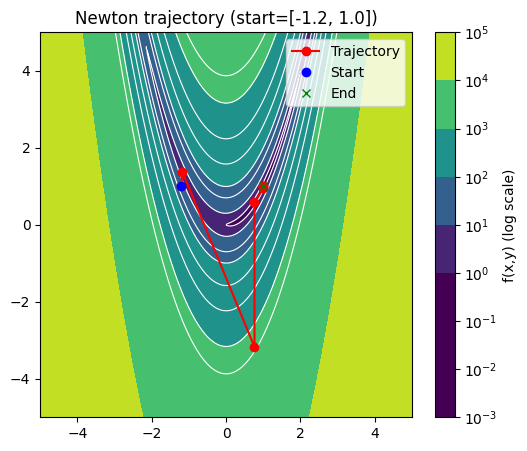

Initial guess [0.0, 0.0]:
  Iterations: 3
  Final point: [1. 1.]
  Final value: 0.000000
  Final grad norm: 0.00e+00
  Comment: (students fill in)



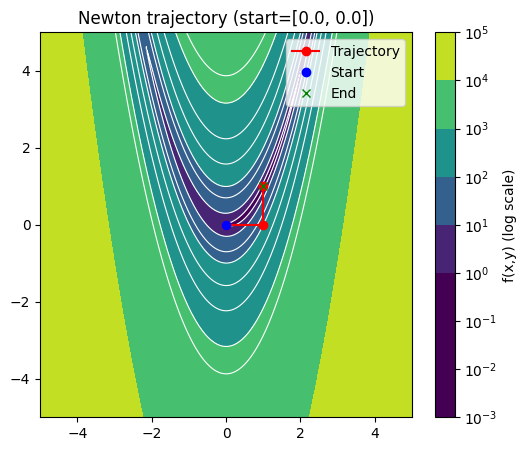

Initial guess [2.0, 2.0]:
  Iterations: 6
  Final point: [1. 1.]
  Final value: 0.000000
  Final grad norm: 5.77e-15
  Comment: (students fill in)



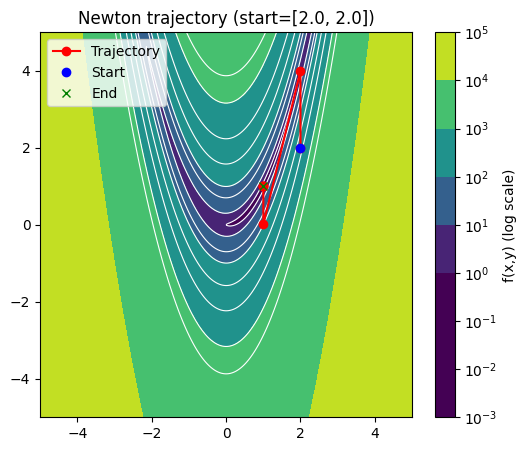

In [12]:
guesses = [[-1.2, 1.0], [0.0, 0.0], [2.0, 2.0]]

for g0 in guesses:
    x_star, hist = newton_method(f_rosenbrock, Grad, Hessian, g0)
    print(f"Initial guess {g0}:")
    print(f"  Iterations: {len(hist)}")
    print(f"  Final point: {x_star}")
    print(f"  Final value: {f_rosenbrock(x_star):.6f}")
    print(f"  Final grad norm: {hist[-1]['grad_norm']:.2e}")
    print("  Comment: (students fill in)\n")

    # Call the plotting function
    plot_trajectory(hist, f"Newton trajectory (start={g0})")
